In [1]:
import NNMFit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import matplotlib.font_manager as font_manager
font_axis_label = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }
font_title = {'family': 'serif',
        'color':  'black',
        'weight': 'bold',
        'size': 20,
        }
font_legend = font_manager.FontProperties(family='serif',
                                   weight='normal',
                                   style='normal', size=13)

plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams.update({'font.family':'serif'})

In [3]:
import os
save_path  = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step2_hese_flavor/plots_fit_result"
os.makedirs(save_path, exist_ok=True)

In [4]:
def get_1sigma(scan, parameter, bestfit_val, threshold=1.0):
    """Find where dllh crosses threshold via sign-change detection + linear interpolation."""
    scan_sorted = scan.sort_values(parameter).reset_index(drop=True)
    x = scan_sorted[parameter].values
    delta = scan_sorted["dllh"].values - threshold

    sign_changes = np.where(np.diff(np.sign(delta)))[0]
    roots = []
    for idx in sign_changes:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = delta[idx], delta[idx + 1]
        roots.append(x0 - y0 * (x1 - x0) / (y1 - y0))

    roots = np.array(roots)
    lower = roots[roots < bestfit_val]
    upper = roots[roots > bestfit_val]

    err_lo = bestfit_val - lower[-1] if len(lower) else np.nan
    err_hi = upper[0] - bestfit_val if len(upper) else np.nan
    return err_lo, err_hi

In [ ]:
# new fits with updated data, muon template, bdts
fit_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step2_hese_flavor"    

scan_dir_dict = {
    # first scan, 50 freefits
    "nbestfit20_all_param_2sigma_1D_10steps": 
        f"{fit_path}/data_fits_parameter_scan/nbestfit20_all_param_2sigma_1D_10steps",

    # more in depth scan of certain parameters
    "nbestfit50_zoom_param_1D_20steps": 
        f"{fit_path}/data_fits_parameter_scan/nbestfit50_zoom_param_1D_20steps",
}

In [7]:
drop_unsuccessful = True
scan_dict = {}
bestfits = {}

for name, scan_dir in scan_dir_dict.items():
    print(name)
    # use force_read if new scan points are produced
    scan_dict[name] = NNMFit.utilities.ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    bestfits[name] = scan_dict[name].get_freefit(drop_unsuccessful="True")

all_param_2sigma_1D_10steps


## Best fit comparison

Compare best fit parameter values across all scans and identify which optimizer found the lowest likelihood.

In [8]:
# Compare best fit values across all scans
df_compare = pd.DataFrame({name: bestfits[name] for name in scan_dir_dict}).T
display(df_compare)

best_name = df_compare["llh"].idxmin()
print(f"\nBest likelihood: '{best_name}'  (llh = {df_compare.loc[best_name, 'llh']:.6f})")
for name in scan_dir_dict:
    if name != best_name:
        delta = df_compare.loc[name, "llh"] - df_compare.loc[best_name, "llh"]
        print(f"  {name} is worse by dllh = {delta:.4f}")

,CR_grad,astro_norm,astro_nue_ratio,astro_nutau_ratio,barr_h,barr_w,barr_y,barr_z,conv_norm,delta_gamma,...,fit_success,gamma_astro,ice_abs,ice_crystal,ice_holep0,ice_holep1,ice_scat,llh,muongun_norm,prompt_norm
all_param_2sigma_1D_10steps,-0.010329,5.621607,0.501716,0.0,0.00054,0.002066,0.018147,0.011323,1.007922,-0.001315,...,True,2.95017,1.087183,0.910034,0.001491,-0.033464,0.928633,188.116052,1.208774,0.0



Best likelihood: 'all_param_2sigma_1D_10steps'  (llh = 188.116052)


## Free fit parameter distributions

Histograms of all free parameters across the best-fit ensemble. The red line marks the best fit value for each parameter.

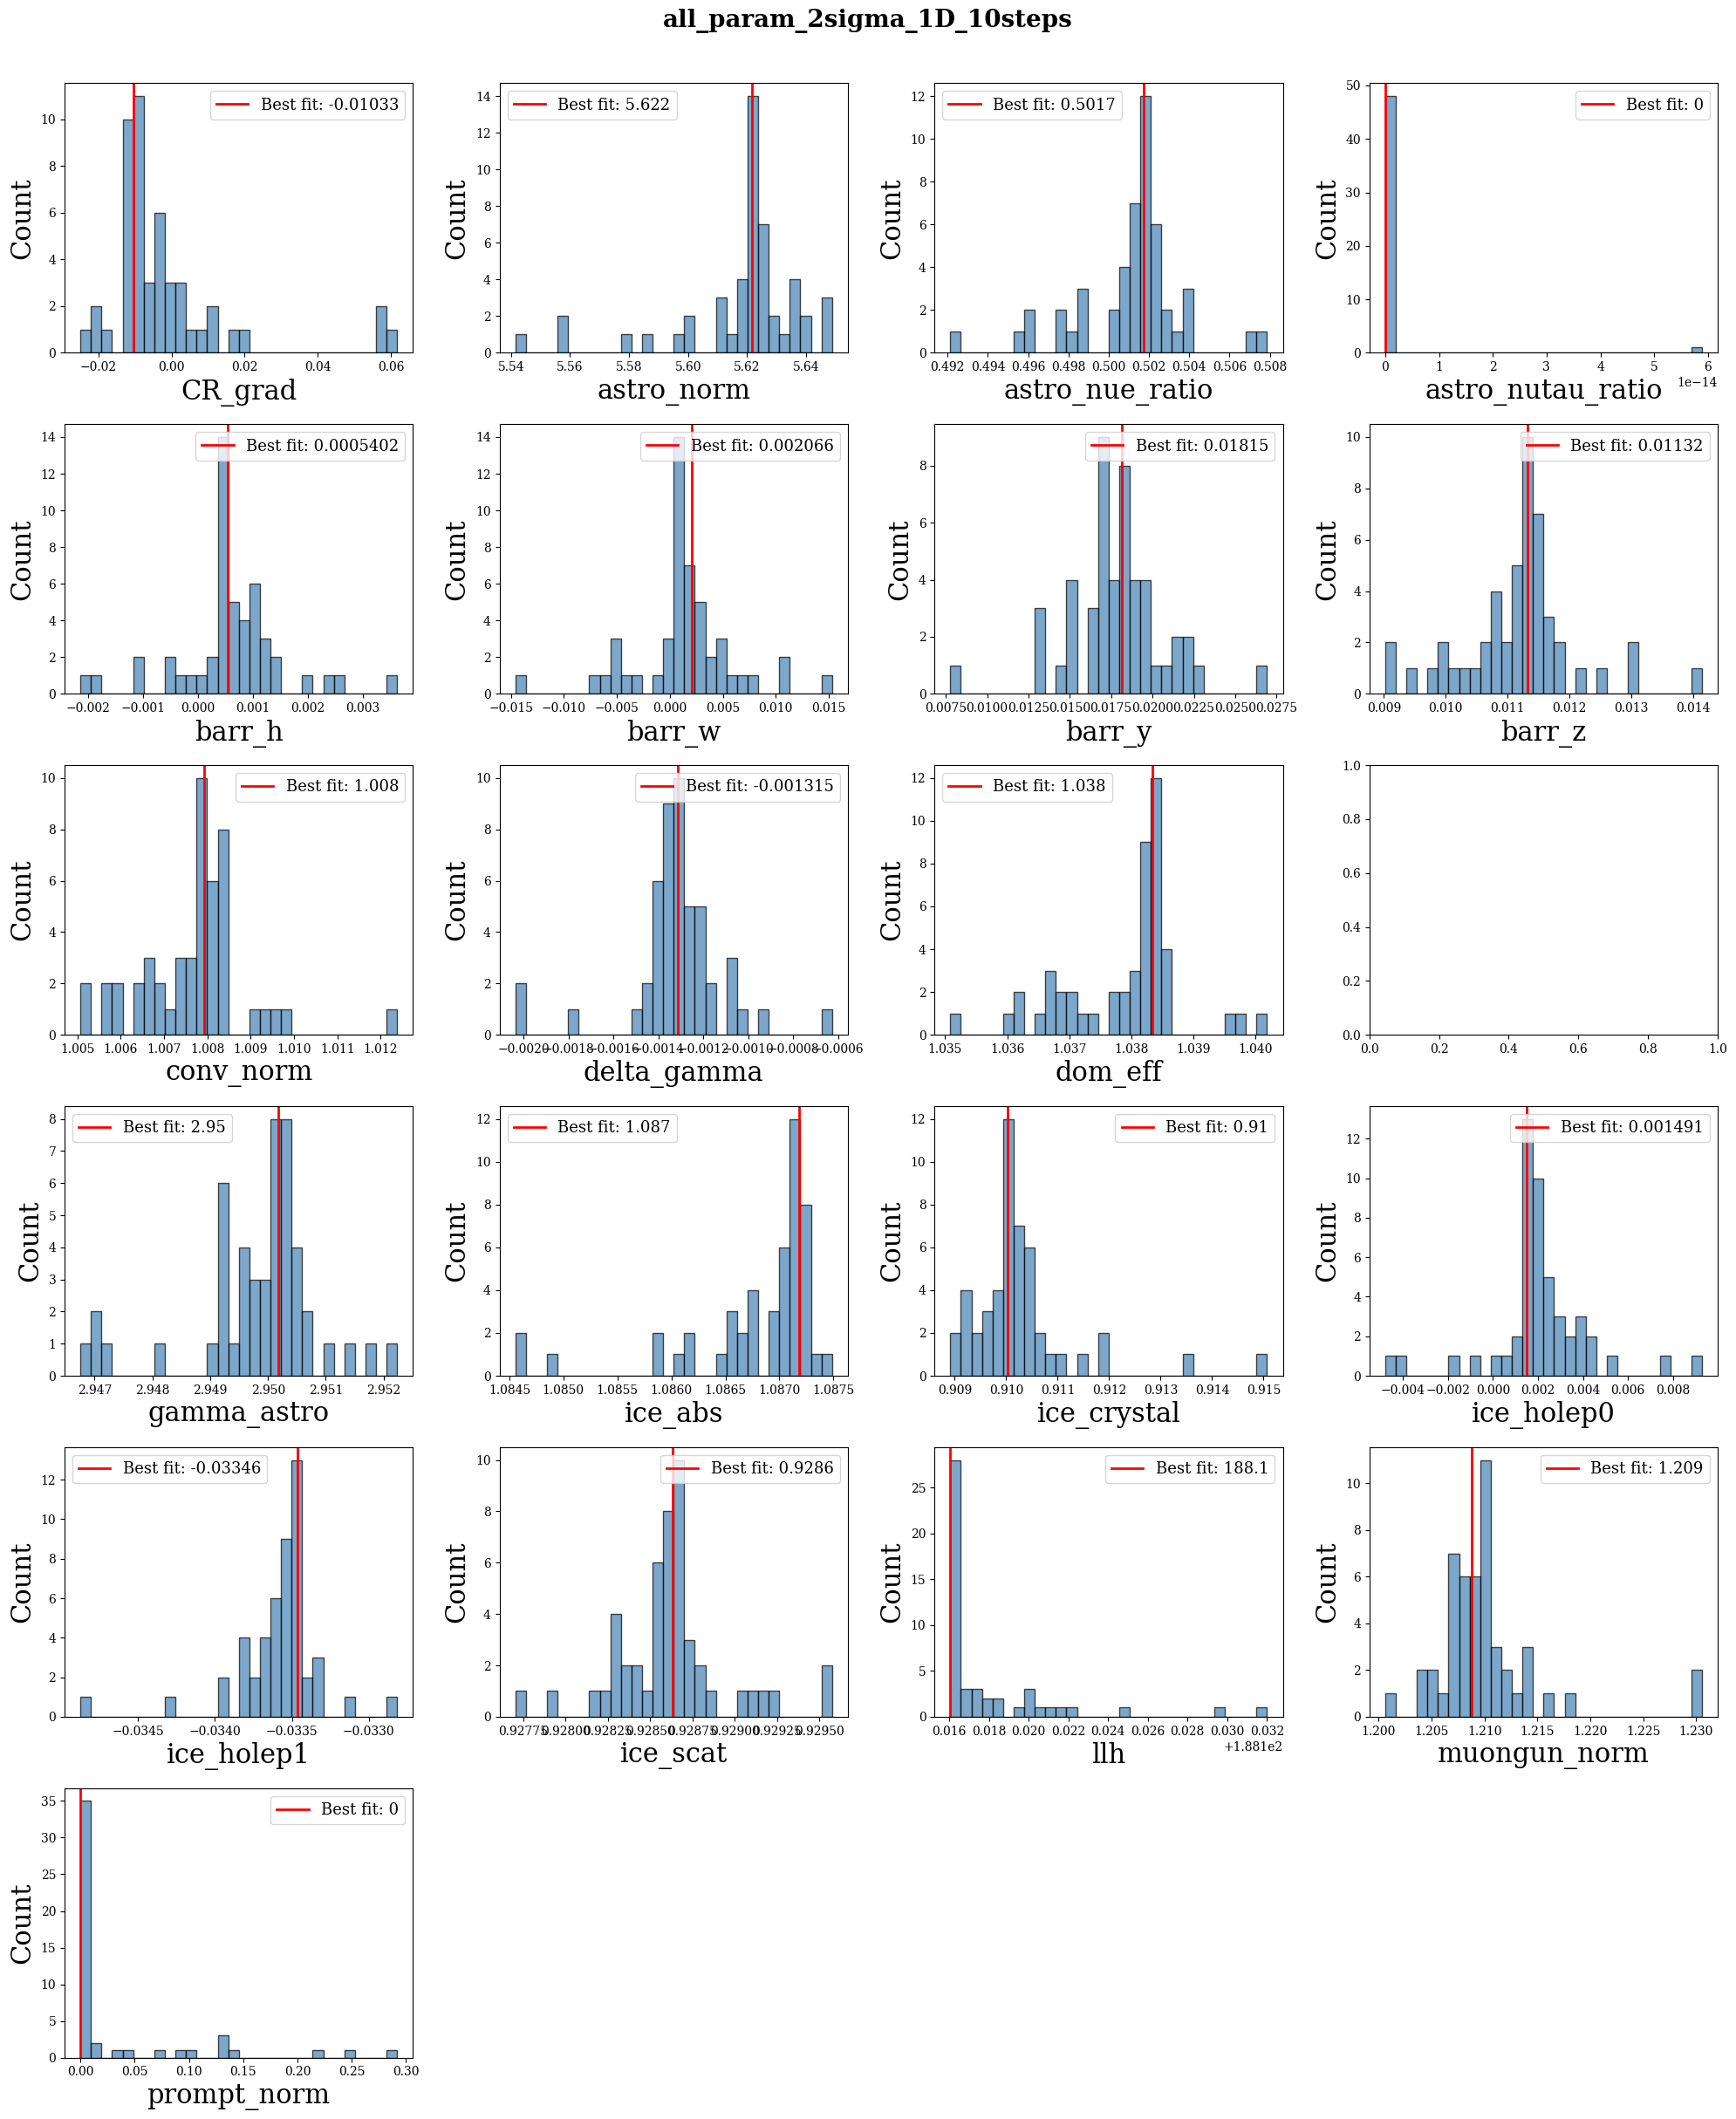

In [9]:
for name in scan_dir_dict:
    freefit_df = scan_dict[name].get_raw_df().loc["freefit"]
    variables = freefit_df.keys()
    bestfit = bestfits[name]

    ncols = 4
    nrows = int(np.ceil(len(variables) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    fig.suptitle(name, **font_title, y=1.01)
    axes = axes.flatten()

    for i, var in enumerate(variables):
        if var == "fit_success": continue
        ax = axes[i]
        values = freefit_df[var].dropna()
        ax.hist(values, bins=30, color="steelblue", alpha=0.7, edgecolor="black")
        if var in bestfit:
            bf_val = bestfit[var]
            ax.axvline(x=bf_val, color="red", linewidth=2, label=f"Best fit: {bf_val:.4g}")
            ax.legend(prop=font_legend)
        ax.set_xlabel(var, fontdict=font_axis_label)
        ax.set_ylabel("Count", fontdict=font_axis_label)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{save_path}/freefit_param_hist_{name}.png")
    plt.show()


## Best fit parameters

Parameters from the best scan printed in `input_params` YAML format, ready to paste into the analysis config.

In [10]:
bf = bestfits[best_name]

signal      = ["astro_norm", "gamma_astro", "astro_nue_ratio", "astro_nutau_ratio"]
flux_nuis   = ["conv_norm", "prompt_norm", "muongun_norm",
               "CR_grad", "barr_h", "barr_w", "barr_y", "barr_z", "delta_gamma"]
det_nuis    = ["dom_eff", "ice_abs", "ice_crystal", "ice_holep0", "ice_holep1", "ice_scat"]

lines = [f"# best fit from scan: {best_name}", "input_params:"]
for label, group in [("signal", signal), ("flux nuisance", flux_nuis), ("detector nuisance", det_nuis)]:
    lines.append(f"  ### {label}")
    for p in group:
        lines.append(f"  {p}: {bf[p]}")
    lines.append("")

print("\n".join(lines))

# best fit from scan: all_param_2sigma_1D_10steps
input_params:
  ### signal
  astro_norm: 5.621607394704795
  gamma_astro: 2.95017031896454
  astro_nue_ratio: 0.501715716968124
  astro_nutau_ratio: 0.0

  ### flux nuisance
  conv_norm: 1.0079217648802568
  prompt_norm: 0.0
  muongun_norm: 1.2087743273030822
  CR_grad: -0.010328603465562714
  barr_h: 0.0005402029183753564
  barr_w: 0.0020656203891569608
  barr_y: 0.018146502491597636
  barr_z: 0.01132341888981059
  delta_gamma: -0.0013152698469300816

  ### detector nuisance
  dom_eff: 1.0383312390622896
  ice_abs: 1.0871825172875766
  ice_crystal: 0.9100337494657894
  ice_holep0: 0.0014908108799228303
  ice_holep1: -0.033464001250212726
  ice_scat: 0.9286325642849093



## All-parameter likelihood scans

$-2\Delta\log\mathcal{L}$ profiles for all 17 free parameters from the best scan. The red shaded band marks the 1σ interval; dotted verticals bound it.

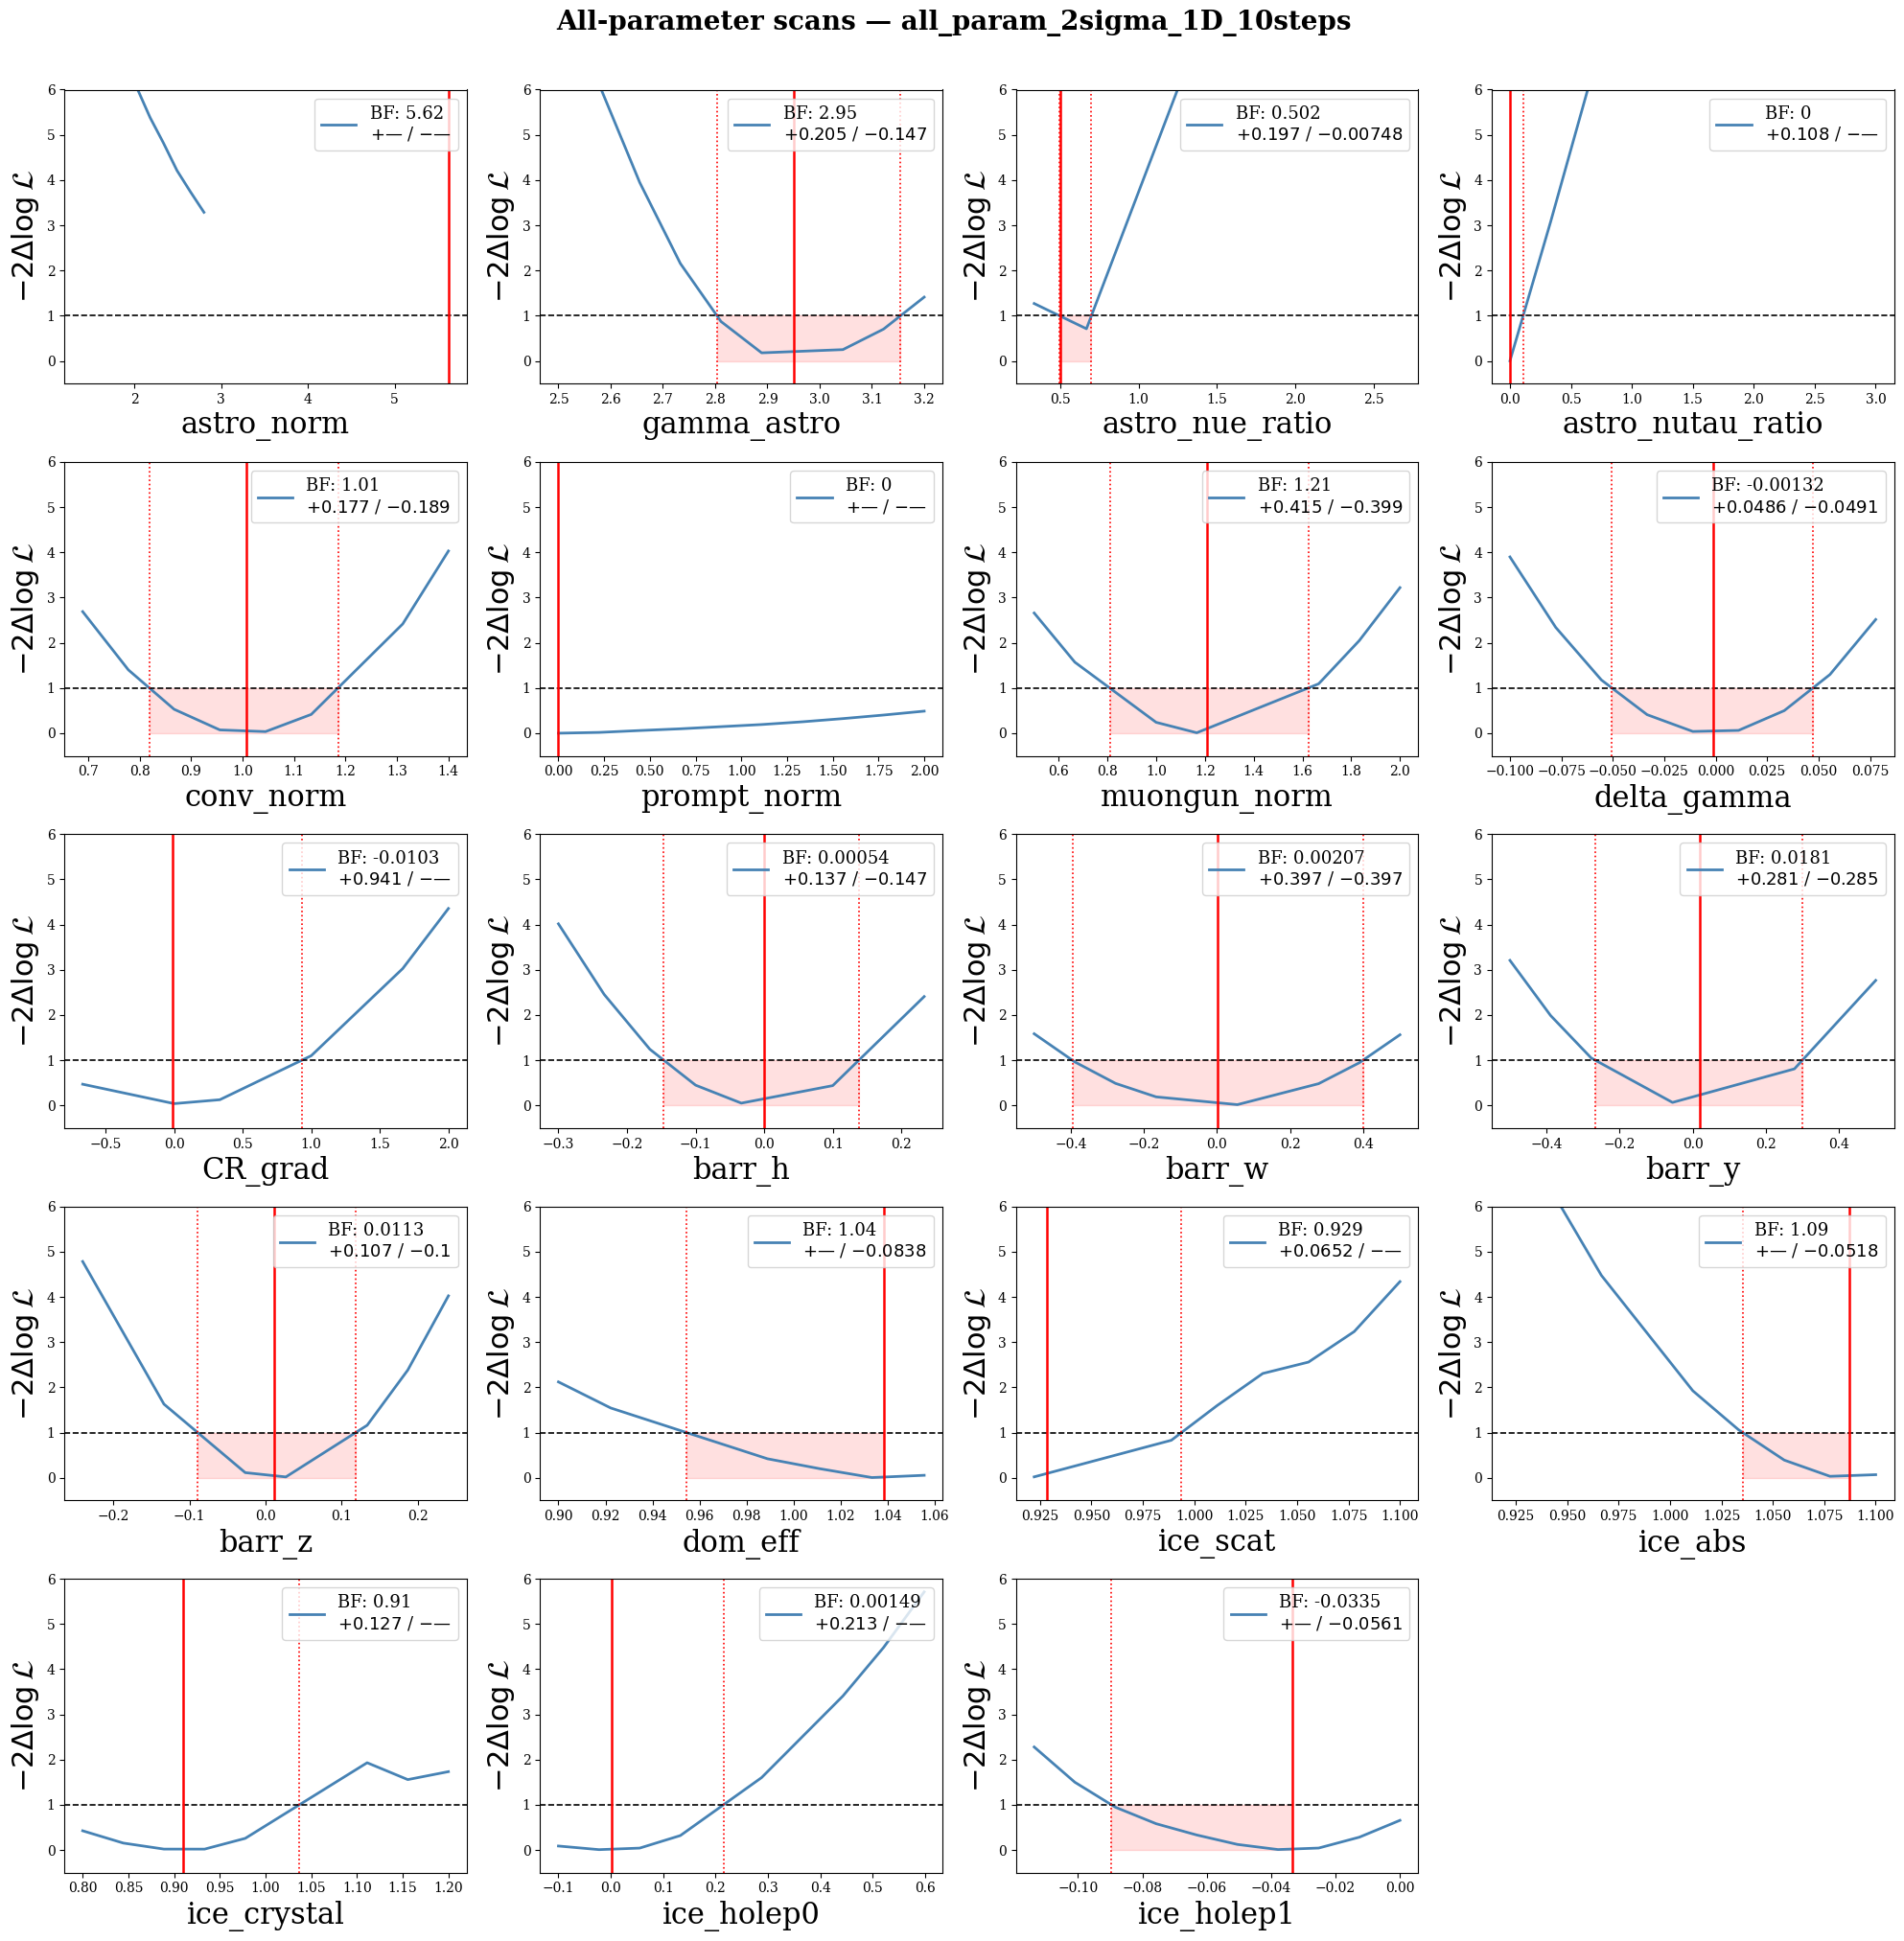

In [11]:
all_parameters = [
    "astro_norm", "gamma_astro", "astro_nue_ratio", "astro_nutau_ratio",
    "conv_norm", "prompt_norm", "muongun_norm",
    "delta_gamma", "CR_grad",
    "barr_h", "barr_w", "barr_y", "barr_z",
    "dom_eff", "ice_scat", "ice_abs", "ice_crystal", "ice_holep0", "ice_holep1",
]

ncols = 4
nrows = int(np.ceil(len(all_parameters) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle(f"All-parameter scans — {best_name}", **font_title, y=1.01)
axes = axes.flatten()

scan_results = {}

for i, parameter in enumerate(all_parameters):
    ax = axes[i]
    try:
        scan = scan_dict[best_name].get_scan_df(param_name=parameter, drop_unsuccessful=drop_unsuccessful)
        bestfit_val = bestfits[best_name][parameter]
        err_lo, err_hi = get_1sigma(scan, parameter, bestfit_val)
        scan_results[parameter] = (bestfit_val, err_lo, err_hi)

        scan_sorted = scan.sort_values(parameter)
        ax.plot(scan_sorted[parameter], scan_sorted["dllh"], color="steelblue", linewidth=2)
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2)
        ax.axvline(bestfit_val, color="red", linewidth=1.8, label=f"BF: {bestfit_val:.3g}")
        if not np.isnan(err_lo):
            ax.axvline(bestfit_val - err_lo, color="red", linestyle=":", linewidth=1.2)
            ax.fill_betweenx([0, 1], bestfit_val - err_lo,
                             bestfit_val + err_hi if not np.isnan(err_hi) else bestfit_val,
                             color="red", alpha=0.12)
        if not np.isnan(err_hi):
            ax.axvline(bestfit_val + err_hi, color="red", linestyle=":", linewidth=1.2)

        lo_str = f"{err_lo:.3g}" if not np.isnan(err_lo) else "—"
        hi_str = f"{err_hi:.3g}" if not np.isnan(err_hi) else "—"
        ax.legend([f"BF: {bestfit_val:.3g}\n$+{hi_str}$ / $-{lo_str}$"],
                  prop=font_legend, loc="upper right")
    except Exception as e:
        ax.text(0.5, 0.5, f"No scan\n({e})", ha="center", va="center", transform=ax.transAxes)
        scan_results[parameter] = (bestfits[best_name].get(parameter, np.nan), np.nan, np.nan)

    ax.set_xlabel(parameter, fontdict=font_axis_label)
    ax.set_ylabel(r"$-2\Delta\log\mathcal{L}$", fontdict=font_axis_label)
    ax.set_ylim(-0.5, 6)

for j in range(len(all_parameters), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f"{save_path}/all_param_scan_bestfit.png")
plt.show()


## Best fit results — LaTeX table

Best fit values with 1σ asymmetric errors for all parameters, formatted as a LaTeX table.

In [15]:
n_decimals = 3

param_labels = {
    "astro_norm":    r"$\Phi_{0,\nu_\mu}$",
    "gamma_astro":   r"$\gamma_\mathrm{astro}$",
    "conv_norm":     r"$\Phi_\mathrm{conv}$",
    "prompt_norm":   r"$\Phi_\mathrm{prompt}$",
    "muongun_norm":  r"$\Phi_\mathrm{muon}$",
    "delta_gamma":   r"$\Delta\gamma_{\rm CR}$",
    "CR_grad":       r"CR grad",
    "barr_h":        r"Barr $h$",
    "barr_w":        r"Barr $w$",
    "barr_y":        r"Barr $y$",
    "barr_z":        r"Barr $z$",
    "dom_eff":       r"DOM eff.",
    "ice_scat":      r"Ice scattering",
    "ice_abs":       r"Ice absorption",
    "ice_crystal":   r"Ice crystal",
    "ice_holep0":    r"Ice hole $p_0$",
    "ice_holep1":    r"Ice hole $p_1$",
}

group_labels = {
    "astro_norm":   "Signal",
    "gamma_astro":  None,
    "conv_norm":    "Flux nuisance",
    "prompt_norm":  None,
    "muongun_norm": None,
    "delta_gamma":  None,
    "CR_grad":      None,
    "barr_h":       None,
    "barr_w":       None,
    "barr_y":       None,
    "barr_z":       None,
    "dom_eff":      "Detector nuisance",
    "ice_scat":     None,
    "ice_abs":      None,
    "ice_crystal":  None,
    "ice_holep0":   None,
    "ice_holep1":   None,
}

lines = [
    r"\begin{table}[h]",
    r"  \centering",
    r"  \caption{Best fit values with $1\sigma$ asymmetric uncertainties.}",
    r"  \label{tab:bestfit}",
    r"  \begin{tabular}{l r r r}",
    r"    \hline\hline",
    r"    Parameter & Best fit & $-1\sigma$ & $+1\sigma$ \\",
    r"    \hline",
]

def fmt(v):
    return r"---" if np.isnan(v) else f"{v:.{n_decimals}f}"

current_group = None
for p in all_parameters:
    grp = group_labels.get(p)
    if grp is not None and grp != current_group:
        lines.append(r"    \hline")
        lines.append(r"    \multicolumn{4}{l}{\textbf{" + grp + r"}} \\")
        lines.append(r"    \hline")
        current_group = grp

    bf_val, err_lo, err_hi = scan_results.get(p, (bestfits[best_name].get(p, float("nan")), float("nan"), float("nan")))
    label = param_labels.get(p, p)
    lines.append(f"    {label} & ${fmt(bf_val)}$ & ${fmt(err_lo)}$ & ${fmt(err_hi)}$ \\\\")

lines += [
    r"    \hline\hline",
    r"  \end{tabular}",
    r"\end{table}",
]

latex = "\n".join(lines)
print(latex)


\begin{table}[h]
  \centering
  \caption{Best fit values with $1\sigma$ asymmetric uncertainties.}
  \label{tab:bestfit}
  \begin{tabular}{l r r r}
    \hline\hline
    Parameter & Best fit & $-1\sigma$ & $+1\sigma$ \\
    \hline
    \hline
    \multicolumn{4}{l}{\textbf{Signal}} \\
    \hline
    $\Phi_{0,\nu_\mu}$ & $1.963$ & $0.507$ & $0.557$ \\
    $\gamma_\mathrm{astro}$ & $2.851$ & $0.153$ & $0.146$ \\
    \hline
    \multicolumn{4}{l}{\textbf{Flux nuisance}} \\
    \hline
    $\Phi_\mathrm{conv}$ & $1.045$ & $0.204$ & $0.137$ \\
    $\Phi_\mathrm{prompt}$ & $0.000$ & $---$ & $1.771$ \\
    $\Phi_\mathrm{muon}$ & $1.381$ & $0.391$ & $0.408$ \\
    $\Delta\gamma_{\rm CR}$ & $-0.002$ & $0.048$ & $0.046$ \\
    CR grad & $-0.198$ & $---$ & $1.025$ \\
    Barr $h$ & $0.003$ & $0.146$ & $0.145$ \\
    Barr $w$ & $0.023$ & $0.406$ & $0.395$ \\
    Barr $y$ & $0.084$ & $0.306$ & $0.253$ \\
    Barr $z$ & $0.044$ & $0.113$ & $0.082$ \\
    \hline
    \multicolumn{4}{l}{\textbf{Detector n

## Comparison with previous analysis

Side-by-side LaTeX table of best fit values from the previous HESE-12 analysis and this analysis.

In [16]:
# HESE-12 flavor: (best_fit, err_lo, err_hi). None = parameter not in that analysis.
hese12_results = {
    "astro_norm":   (2.53,    1.49,   1.78),
    "gamma_astro":  (2.84,    0.18,   0.19),
    "conv_norm":    (0.99,    0.20,   0.19),
    "prompt_norm":  (0.0,     0.0,    2.25),
    "muongun_norm": (1.16,    0.43,   0.42),
    "delta_gamma":  (-0.00,   1.0,    1.0),
    "CR_grad":      (0.042,   1.0,    2.0),
    "barr_h":       (0.0,     0.5,    0.5),
    "barr_w":       (0.0,     0.5,    0.5),
    "barr_y":       (0.0,     0.5,    0.5),
    "barr_z":       (0.0,     0.5,    0.5),
    "dom_eff":      (1.04,    0.04,   0.06),
    "ice_scat":     (0.98,    0.04,   0.04),
    "ice_abs":      (0.99,    0.04,   0.04),
    "ice_crystal":  None,
    "ice_holep0":   (-0.27,   0.38,   0.28),
    "ice_holep1":   (-0.08,   0.05,   0.04),
}

# HESE-7.5: values given as (bf, CL_lo, CL_hi); errors computed as bf - CL_lo and CL_hi - bf.
hese75_results = {
    "astro_norm":   (6.37/3,  6.37/3 - 4.75/3,  7.83/3 - 6.37/3),
    "gamma_astro":  (2.87,    2.87 - 2.68,       3.08 - 2.87),
    "conv_norm":    (1.01,    1.01 - 0.67,        1.35 - 1.01),
    "prompt_norm":  (0.0,     0.0,                5.34 - 0.0),
    "muongun_norm": (1.19,    1.19 - 0.75,        1.64 - 1.19),
    "delta_gamma":  (-0.053,  -0.053 - (-0.184),  -0.005 - (-0.053)),
    "CR_grad":      None,
    "barr_h":       None,
    "barr_w":       None,
    "barr_y":       None,
    "barr_z":       None,
    "dom_eff":      (0.952,   0.952 - 0.886,      1.045 - 0.952),
    "ice_scat":     None,
    "ice_abs":      None,
    "ice_crystal":  None,
    "ice_holep0":   None,
    "ice_holep1":   None,
}

def fmt(v):
    return r"---" if np.isnan(v) else f"{v:.{n_decimals}f}"

def fmt_entry(entry):
    if entry is None:
        return "---"
    bf, lo, hi = entry
    return f"${bf:.{n_decimals}f}^{{+{hi:.{n_decimals}f}}}_{{-{lo:.{n_decimals}f}}}$"

lines = [
    r"\begin{table}[h]",
    r"  \centering",
    r"  \caption{Comparison of best fit values with $1\sigma$ asymmetric uncertainties"
    r" across analyses.}",
    r"  \label{tab:bestfit_comparison}",
    r"  \begin{tabular}{l r r r}",
    r"    \hline\hline",
    r"    Parameter & HESE-7.5 & HESE-12 flavor & This analysis \\",
    r"    \hline",
]

current_group = None
for p in all_parameters:
    grp = group_labels.get(p)
    if grp is not None and grp != current_group:
        lines.append(r"    \hline")
        lines.append(r"    \multicolumn{4}{l}{\textbf{" + grp + r"}} \\")
        lines.append(r"    \hline")
        current_group = grp

    h75  = fmt_entry(hese75_results.get(p))
    h12  = fmt_entry(hese12_results.get(p))

    bf_val, err_lo, err_hi = scan_results.get(p, (bestfits[best_name].get(p, float("nan")), float("nan"), float("nan")))
    curr = f"${fmt(bf_val)}^{{+{fmt(err_hi)}}}_{{-{fmt(err_lo)}}}$"

    label = param_labels.get(p, p)
    lines.append(f"    {label} & {h75} & {h12} & {curr} \\\\")

lines += [
    r"    \hline\hline",
    r"  \end{tabular}",
    r"\end{table}",
]

print("\n".join(lines))


\begin{table}[h]
  \centering
  \caption{Comparison of best fit values with $1\sigma$ asymmetric uncertainties across analyses.}
  \label{tab:bestfit_comparison}
  \begin{tabular}{l r r r}
    \hline\hline
    Parameter & HESE-7.5 & HESE-12 flavor & This analysis \\
    \hline
    \hline
    \multicolumn{4}{l}{\textbf{Signal}} \\
    \hline
    $\Phi_{0,\nu_\mu}$ & $2.123^{+0.487}_{-0.540}$ & $2.530^{+1.780}_{-1.490}$ & $1.963^{+0.557}_{-0.507}$ \\
    $\gamma_\mathrm{astro}$ & $2.870^{+0.210}_{-0.190}$ & $2.840^{+0.190}_{-0.180}$ & $2.851^{+0.146}_{-0.153}$ \\
    \hline
    \multicolumn{4}{l}{\textbf{Flux nuisance}} \\
    \hline
    $\Phi_\mathrm{conv}$ & $1.010^{+0.340}_{-0.340}$ & $0.990^{+0.190}_{-0.200}$ & $1.045^{+0.137}_{-0.204}$ \\
    $\Phi_\mathrm{prompt}$ & $0.000^{+5.340}_{-0.000}$ & $0.000^{+2.250}_{-0.000}$ & $0.000^{+1.771}_{----}$ \\
    $\Phi_\mathrm{muon}$ & $1.190^{+0.450}_{-0.440}$ & $1.160^{+0.420}_{-0.430}$ & $1.381^{+0.408}_{-0.391}$ \\
    $\Delta\gamma_{\rm C